## Evaluate the consistency and quality of sequences sampled by PEINT variants

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
tqdm.pandas()

## Eval on test set donor 4 transitions

In [4]:
samples_dir = "../results/gen_eval"
ctmc_mat_exp_df = pd.read_csv(f"{samples_dir}/ctmc_mat_exp.csv")
ctmc_gillespie_df = pd.read_csv(f"{samples_dir}/ctmc_gillespie.csv")
peint_df = pd.read_csv(f"{samples_dir}/peint.csv")

In [5]:
peint_df.head()

,real_parent_hv,real_parent_lt,real_child_hv,real_child_lt,sim_child_hv,sim_child_lt,branch_length,branch_bin,sim_child_hv_plddt,sim_child_lt_plddt
0,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,QVQLVESGGGVVQPGRSLRLSCAASGFTFSTYGMHWVRQAPGKGLE...,EIVLTQSPGSLSLSPGERATLSCRVSQSVSSTYLVWYQQKPGQAPR...,QVQVVESGGGVVQPGRSLRLSCVASGFTFSNSGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVGSSYLAWYQQKPGQAPR...,1.738925,7,NaN,NaN
1,EVQLVESGGGLVQPGGSLKLSCAASGFTFSGSAMHWVRQASGKGLE...,DIVMTQSPLSLPVTPGEPASISCRSSQSLLHSNGYNYLDWYLQKPG...,EVQLVESGGGLVQPGGSLKLSCAASGFIFSDYDMHWVRQASGKGLE...,DIVMTQSPLSLPVTPGEPASISCRSSQSLLHSNGYNFLDWYLQKPG...,AVQLVESGGGLVQPGGSLKLSCVASGFTFSDSGIHWVRQASGKGLE...,NIVMTQSPLSLPVTPGEPASISCRSSQSLLHSNGNNYLDWYLQKPG...,1.699369,7,NaN,NaN
2,EVQLVESGGGLVQPGGSLKLSCAASGFIFSDYDMHWVRQASGKGLE...,DIVMTQSPLSLPVTPGEPASISCRSSQSLLHSNGYNFLDWYLQKPG...,EVQLVESGGGLVQPGGSLKLSCVASGFIFSAYDIHWVRQASGKGLE...,DIVMTQSPLSLPVTPGESASISCRSNQSLLHSNGYNFLDWYLQKPG...,EVQLVESGGGLVQPGGSLKLSCAASGFIFSDYDMHWVRQASGKGLE...,DIVMTQSPLSLPVTPGEPASISCRSSQSLLHSNGYNFLDWYLQKPG...,1.036848,5,NaN,NaN
3,EVQLVESGGGLVQPGGSLKLSCAASGFIFSDYDMHWVRQASGKGLE...,DIVMTQSPLSLPVTPGEPASISCRSSQSLLHSNGYNFLDWYLQKPG...,EVQLVESGGGLVQPGGSLKLSCAASGFIFSDYDVHWVRQASGKGLE...,DIVMTQSPLSLPVTPGEPASISCRSSQSLLHSNGYYFLDWYLQKPG...,EVQLVESGGGLVQPGGSLKLSCASSGFIFSDYDMHWVRQASGKGLE...,DIVMTQSPLSLPVTPGEPASISCRSSQSLLHSNGYNFLDWYLQKPG...,0.718552,4,NaN,NaN
4,EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYWMSWVRQAPGKGLE...,DIVMTQSPLSLPVTPGEPASISCRSSQSLLHSNGYNYLDWYLQKPG...,EVQLVESGGDLVQPGGSLRLSCAASGFTFSSSWMGWVRQAPGKGLE...,DIVVTQSPLSLPVTPGEPASISCRSSQSLLHSNGYNFLDWYLQKPG...,EVQLVESGGGLVQPGGSLKLSCAGSGFSFSEFWMGWFRQAPGQGLE...,DIVMTQSPLSLPVTPGEPASISCRSSQSVLDSNGKSYFDWYLQKPG...,3.579281,9,NaN,NaN


In [6]:
# for each df, calculate the hamming distance between the real parent and the simulated child (for both heavy and light sequences)
def compute_hamming_distance(seq1, seq2):
    assert len(seq1) == len(seq2)
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))

ctmc_mat_exp_df["hmd_hv"] = ctmc_mat_exp_df.progress_apply(lambda row: compute_hamming_distance(row["real_parent_hv"], row["sim_child_hv"]), axis=1)
ctmc_mat_exp_df["hmd_lt"] = ctmc_mat_exp_df.progress_apply(lambda row: compute_hamming_distance(row["real_parent_lt"], row["sim_child_lt"]), axis=1)
ctmc_gillespie_df["hmd_hv"] = ctmc_gillespie_df.progress_apply(lambda row: compute_hamming_distance(row["real_parent_hv"], row["sim_child_hv"]), axis=1)
ctmc_gillespie_df["hmd_lt"] = ctmc_gillespie_df.progress_apply(lambda row: compute_hamming_distance(row["real_parent_lt"], row["sim_child_lt"]), axis=1)
peint_df["hmd_hv"] = peint_df.progress_apply(lambda row: compute_hamming_distance(row["real_parent_hv"], row["sim_child_hv"]), axis=1)
peint_df["hmd_lt"] = peint_df.progress_apply(lambda row: compute_hamming_distance(row["real_parent_lt"], row["sim_child_lt"]), axis=1)
true_df = peint_df.copy()
true_df["hmd_hv"] = true_df.progress_apply(lambda row: compute_hamming_distance(row["real_parent_hv"], row["real_child_hv"]), axis=1)
true_df["hmd_lt"] = true_df.progress_apply(lambda row: compute_hamming_distance(row["real_parent_lt"], row["real_child_lt"]), axis=1)

100%|██████████| 1600/1600 [00:00<00:00, 81285.95it/s]


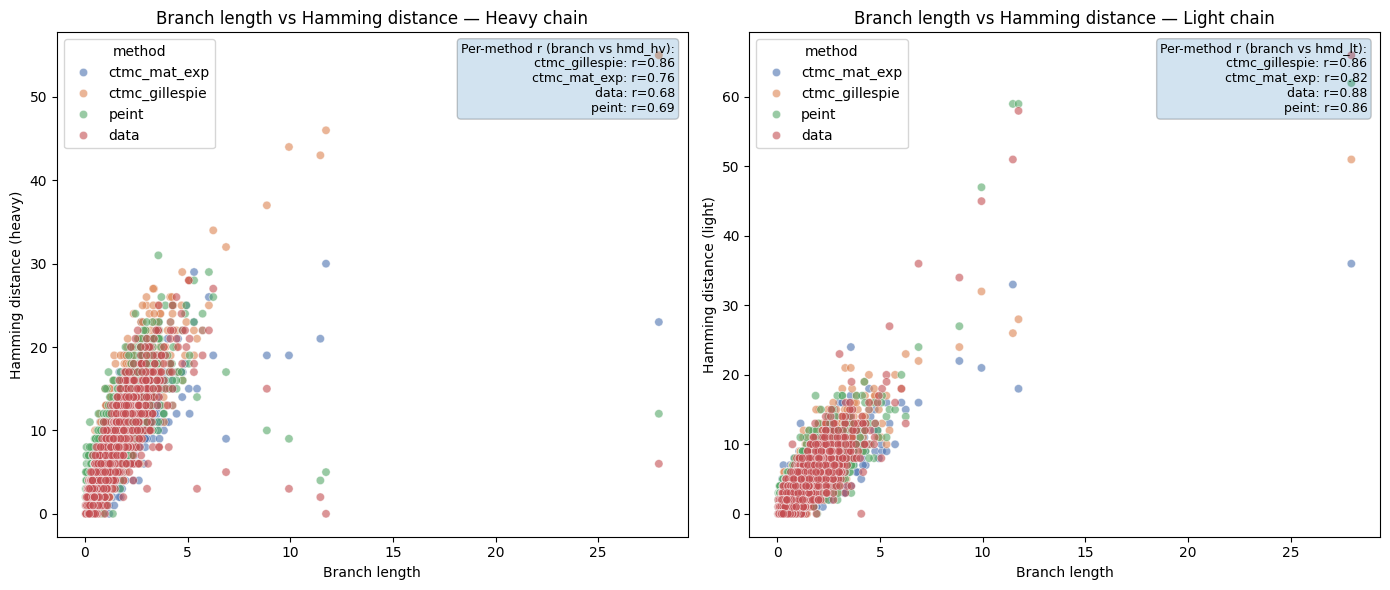

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

data = pd.concat([
    ctmc_mat_exp_df.assign(method="ctmc_mat_exp"),
    ctmc_gillespie_df.assign(method="ctmc_gillespie"),
    peint_df.assign(method="peint"),
    true_df.assign(method="data"),
])

sns.scatterplot(data=data, x="branch_length", y="hmd_hv", hue="method", alpha=0.6, ax=axes[0], palette="deep", legend="full")
axes[0].set_title("Branch length vs Hamming distance — Heavy chain")
axes[0].set_xlabel("Branch length")
axes[0].set_ylabel("Hamming distance (heavy)")

sns.scatterplot(data=data, x="branch_length", y="hmd_lt", hue="method", alpha=0.6, ax=axes[1], palette="deep", legend="full")
axes[1].set_title("Branch length vs Hamming distance — Light chain")
axes[1].set_xlabel("Branch length")
axes[1].set_ylabel("Hamming distance (light)")

# compute Pearson correlation coefficients (per-method and overall) and annotate
corrs_hv = data.groupby("method").apply(lambda g: g["branch_length"].corr(g["hmd_hv"]))
corrs_lt = data.groupby("method").apply(lambda g: g["branch_length"].corr(g["hmd_lt"]))
overall_hv = data["branch_length"].corr(data["hmd_hv"])
overall_lt = data["branch_length"].corr(data["hmd_lt"])

txt_hv = "Per-method r (branch vs hmd_hv):\n" + "\n".join(f"{m}: r={r:.2f}" for m, r in corrs_hv.items())
# txt_hv += f"\nOverall: r={overall_hv:.2f}"

txt_lt = "Per-method r (branch vs hmd_lt):\n" + "\n".join(f"{m}: r={r:.2f}" for m, r in corrs_lt.items())
# txt_lt += f"\nOverall: r={overall_lt:.2f}"

# place the r boxes on the top-right of each subplot
axes[0].text(0.98, 0.98, txt_hv, transform=axes[0].transAxes, ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", alpha=0.2))
axes[1].text(0.98, 0.98, txt_lt, transform=axes[1].transAxes, ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", alpha=0.2))

plt.tight_layout()
plt.show()

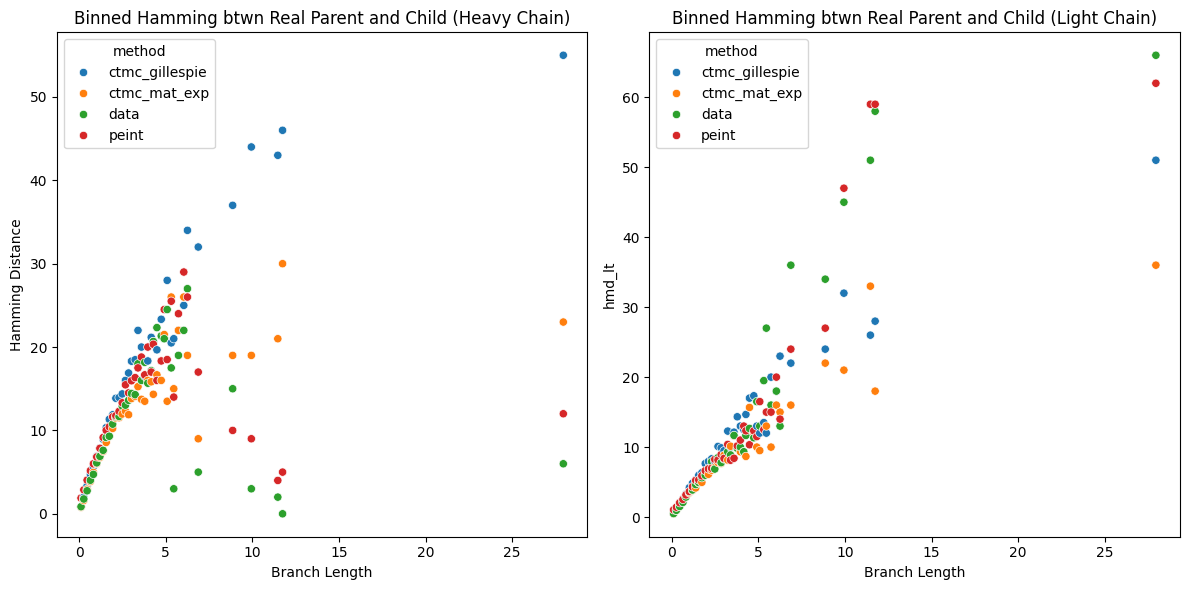

In [9]:
# do this plot again, but now bin by branch length
bl_quantile = data.branch_length.quantile(0.15)
data["bl_bin"] = data.branch_length.astype(float) // bl_quantile.astype(float)

cols_to_keep = ["hmd_hv", "hmd_lt", "method", "bl_bin", "branch_length"]
binned_hv_u = data[cols_to_keep].groupby(by=["bl_bin", "method"]).mean()
binned_lt_u = data[cols_to_keep].groupby(by=["bl_bin", "method"]).mean()
binned_hv_s = data[cols_to_keep].groupby(by=["bl_bin", "method"]).std()
binned_lt_s = data[cols_to_keep].groupby(by=["bl_bin", "method"]).std()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.scatterplot(data=binned_hv_u, x="branch_length", y="hmd_hv", hue="method", ax=ax[0], legend="full")
sns.scatterplot(data=binned_lt_u, x="branch_length", y="hmd_lt", hue="method", ax=ax[1], legend="full")

ax[0].set_title("Binned Hamming btwn Real Parent and Child (Heavy Chain)")
ax[1].set_title("Binned Hamming btwn Real Parent and Child (Light Chain)")
ax[0].set_xlabel("Branch Length")
ax[1].set_xlabel("Branch Length")
ax[0].set_ylabel("Hamming Distance")
ax[0].set_ylabel("Hamming Distance")

plt.tight_layout()
plt.show()

In [28]:
# for each df, keep the rows with plddt scores and scatter plot plddt versus branch length
peint_plddt_vs_bl = peint_df.dropna(subset=["sim_child_hv_plddt", "sim_child_lt_plddt"])
gill_plddt_vs_bl = ctmc_gillespie_df.dropna(subset=["sim_child_hv_plddt", "sim_child_lt_plddt"])
matexp_plddt_vs_bl = ctmc_mat_exp_df.dropna(subset=["sim_child_hv_plddt", "sim_child_lt_plddt"])

## Eval on changing t for single parent sequence

In [10]:
samples_dir = "../results/gen_eval"
ctmc_mat_exp_df = pd.read_csv(f"{samples_dir}/ctmc_mat_exp_vary_t.csv")
ctmc_gillespie_df = pd.read_csv(f"{samples_dir}/ctmc_gillespie_vary_t.csv")
peint_df = pd.read_csv(f"{samples_dir}/peint_vary_t.csv")

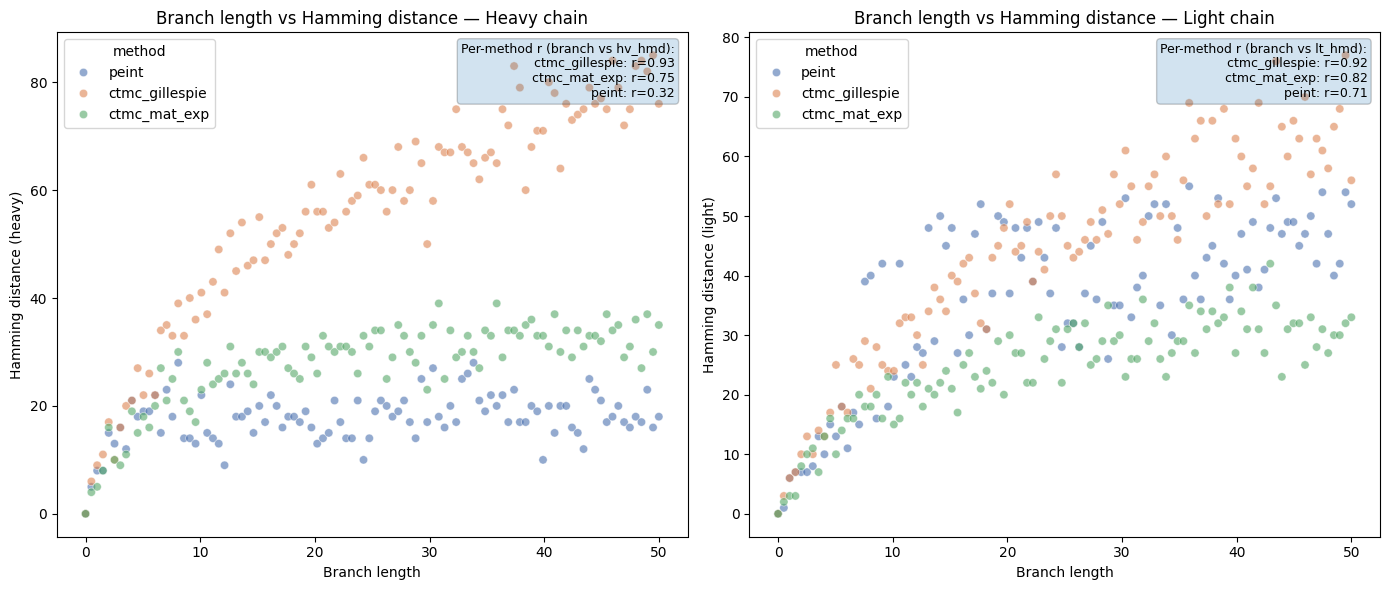

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

data = pd.concat([
    peint_df.assign(method="peint"),
    ctmc_gillespie_df.assign(method="ctmc_gillespie"),
    ctmc_mat_exp_df.assign(method="ctmc_mat_exp"),
])

sns.scatterplot(data=data, x="branch_lengths", y="hv_hmd", hue="method", alpha=0.6, ax=axes[0], palette="deep", legend="full")
axes[0].set_title("Branch length vs Hamming distance — Heavy chain")
axes[0].set_xlabel("Branch length")
axes[0].set_ylabel("Hamming distance (heavy)")

sns.scatterplot(data=data, x="branch_lengths", y="lt_hmd", hue="method", alpha=0.6, ax=axes[1], palette="deep", legend="full")
axes[1].set_title("Branch length vs Hamming distance — Light chain")
axes[1].set_xlabel("Branch length")
axes[1].set_ylabel("Hamming distance (light)")

# compute Pearson correlation coefficients (per-method and overall) and annotate
corrs_hv = data.groupby("method").apply(lambda g: g["branch_lengths"].corr(g["hv_hmd"]))
corrs_lt = data.groupby("method").apply(lambda g: g["branch_lengths"].corr(g["lt_hmd"]))
overall_hv = data["branch_lengths"].corr(data["hv_hmd"])
overall_lt = data["branch_lengths"].corr(data["lt_hmd"])

txt_hv = "Per-method r (branch vs hv_hmd):\n" + "\n".join(f"{m}: r={r:.2f}" for m, r in corrs_hv.items())
# txt_hv += f"\nOverall: r={overall_hv:.2f}"

txt_lt = "Per-method r (branch vs lt_hmd):\n" + "\n".join(f"{m}: r={r:.2f}" for m, r in corrs_lt.items())
# txt_lt += f"\nOverall: r={overall_lt:.2f}"

# place the r boxes on the top-right of each subplot
axes[0].text(0.98, 0.98, txt_hv, transform=axes[0].transAxes, ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", alpha=0.2))
axes[1].text(0.98, 0.98, txt_lt, transform=axes[1].transAxes, ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", alpha=0.2))

plt.tight_layout()
plt.show()

In [47]:
peint_df.head()

,branch_lengths,hv_par,lt_par,hv_seqs,lt_seqs,hv_hmd,lt_hmd,hv_seqs_plddt,lt_seqs_plddt
0,0.000000,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,0,0,86.229152,89.645163
1,0.505051,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,QVQLVESGGGVVQPGRSLRLSCAASGFTFSDYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,5,1,85.996688,89.580253
2,1.010101,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,QVQLVESGGGVVQPGRSLRLSCAASGFTFRNFGMHWVRQAPGKGLQ...,ENVLTQSPGTLSLSPGERATLSCRASQRVSSSYLSWYQQKPGQSPR...,8,6,84.890544,89.373612
3,1.515152,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,QVQLVESGGGVVQPGGSLRLSCAASGFSFSDCGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSNYLAWYQQKPGQAPR...,8,7,83.995358,90.254089
4,2.020202,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,QVQLVESGGGVVQPGGSLRLSCEASGFTFSNFGVNWVRQAPGKGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVISNYLAWYQQKPGQAPR...,15,7,84.065222,89.573191


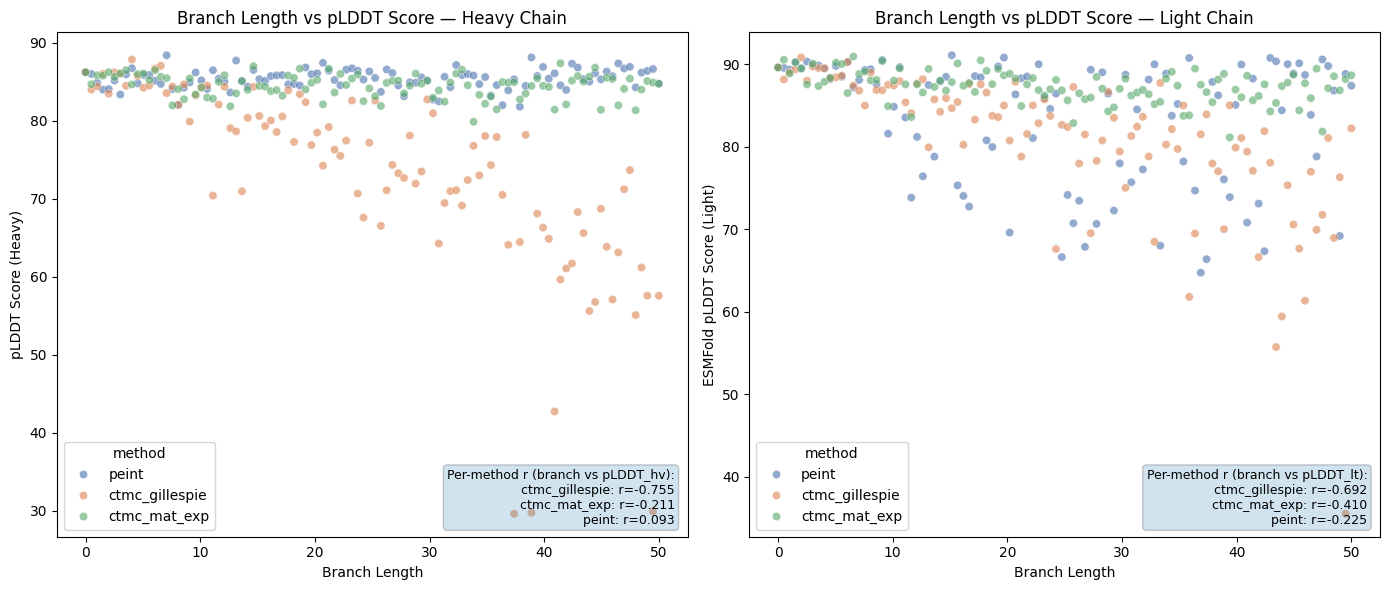

In [15]:
# plot branch length vs plddt colored by method (heavy and light chain side by side)
# Filter rows with pLDDT scores
peint_plddt = peint_df.dropna(subset=["hv_seqs_plddt", "lt_seqs_plddt"])
gill_plddt = ctmc_gillespie_df.dropna(subset=["hv_seqs_plddt", "lt_seqs_plddt"])
matexp_plddt = ctmc_mat_exp_df.dropna(subset=["hv_seqs_plddt", "lt_seqs_plddt"])

# Combine data
plddt_data = pd.concat([
    peint_plddt.assign(method="peint"),
    gill_plddt.assign(method="ctmc_gillespie"),
    matexp_plddt.assign(method="ctmc_mat_exp")
])

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# Heavy chain
sns.scatterplot(
    data=plddt_data, 
    x="branch_lengths", 
    y="hv_seqs_plddt", 
    hue="method", 
    alpha=0.6, 
    ax=axes[0], 
    palette="deep", 
    legend="full"
)
axes[0].set_title("Branch Length vs pLDDT Score — Heavy Chain")
axes[0].set_xlabel("Branch Length")
axes[0].set_ylabel("pLDDT Score (Heavy)")

# Light chain
sns.scatterplot(
    data=plddt_data, 
    x="branch_lengths", 
    y="lt_seqs_plddt", 
    hue="method", 
    alpha=0.6, 
    ax=axes[1], 
    palette="deep", 
    legend="full"
)
axes[1].set_title("Branch Length vs pLDDT Score — Light Chain")
axes[1].set_xlabel("Branch Length")
axes[1].set_ylabel("ESMFold pLDDT Score (Light)")

# Compute Pearson correlation coefficients
corrs_hv = plddt_data.groupby("method").apply(lambda g: g["branch_lengths"].corr(g["hv_seqs_plddt"]))
corrs_lt = plddt_data.groupby("method").apply(lambda g: g["branch_lengths"].corr(g["lt_seqs_plddt"]))

txt_hv = "Per-method r (branch vs pLDDT_hv):\n" + "\n".join(f"{m}: r={r:.3f}" for m, r in corrs_hv.items())
txt_lt = "Per-method r (branch vs pLDDT_lt):\n" + "\n".join(f"{m}: r={r:.3f}" for m, r in corrs_lt.items())

# Place correlation annotations
axes[0].text(0.98, 0.02, txt_hv, transform=axes[0].transAxes, ha="right", va="bottom", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", alpha=0.2))
axes[1].text(0.98, 0.02, txt_lt, transform=axes[1].transAxes, ha="right", va="bottom", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", alpha=0.2))

plt.tight_layout()
plt.show()